### Model Training

In this notebook we train machine learning models to forecast
daily restaurant demand.

The objective is to evaluate how well different models can learn
temporal patterns and demand drivers from the engineered features.

The workflow includes:

• baseline forecasting model  
• machine learning regression models  
• time-series cross-validation  
• model comparison  
• feature importance analysis

In [1]:
"""
Import libraries for model training and evaluation.
"""

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
"""
Load feature-engineered dataset.
"""

df = pd.read_csv("../data/restaurant_features.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.head()

,date,day_of_week,dow,month,year,week_of_year,is_weekend,weekly_factor,seasonal_factor,trend,...,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_14,momentum_1_7,momentum_7_14,dow_sin,dow_cos,month_sin,month_cos
0,2016-01-31,Sunday,6,1,2016,4,1,1.25,1.101734,1.002568,...,171.285714,171.700000,24.533747,27.691789,38.0,-29.0,-0.781831,0.623490,0.500000,0.866025
1,2016-02-01,Monday,0,2,2016,5,0,1.00,1.104683,1.002653,...,171.571429,174.933333,28.641462,28.193601,72.0,4.0,0.000000,1.000000,0.866025,0.500000
2,2016-02-02,Tuesday,1,2,2016,5,0,1.00,1.107601,1.002739,...,171.642857,173.966667,29.319261,28.116809,-30.0,23.0,0.781831,0.623490,0.866025,0.500000
3,2016-02-03,Wednesday,2,2,2016,5,0,1.00,1.110487,1.002824,...,172.785714,171.900000,29.854409,27.532299,-2.0,2.0,0.974928,-0.222521,0.866025,0.500000
4,2016-02-04,Thursday,3,2,2016,5,0,1.00,1.113340,1.002910,...,173.142857,171.866667,29.631065,27.483861,5.0,13.0,0.433884,-0.900969,0.866025,0.500000


In [3]:
"""
Create chronological train/test split.
"""

split_date = "2023-01-01"

train = df[df["date"] < split_date]
test = df[df["date"] >= split_date]

print("Train size:", train.shape)
print("Test size:", test.shape)

Train size: (2527, 37)
Test size: (365, 37)


In [4]:
"""
Define feature matrix and target variable.
"""

target = "total_orders"

features = [
    col for col in df.columns
    if col not in ["date", "total_orders"]
]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [5]:
"""
Baseline model using previous day's demand.
"""

baseline_pred = test["orders_lag_1"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 31.035616438356165


In [6]:
"""
Initialize machine learning models.
"""

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [7]:
"""
Define feature matrix and target variable.
Only numeric features are used for machine learning models.
"""

target = "total_orders"

numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns

features = [
    col for col in numeric_features
    if col != target
]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Number of features:", len(features))

Number of features: 34


In [8]:
"""
Train models and generate predictions.
"""

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)

results_df

,model,MAE,RMSE
0,Linear Regression,12.141465,15.342933
1,Random Forest,13.009369,16.495875
2,Gradient Boosting,12.835001,16.016017


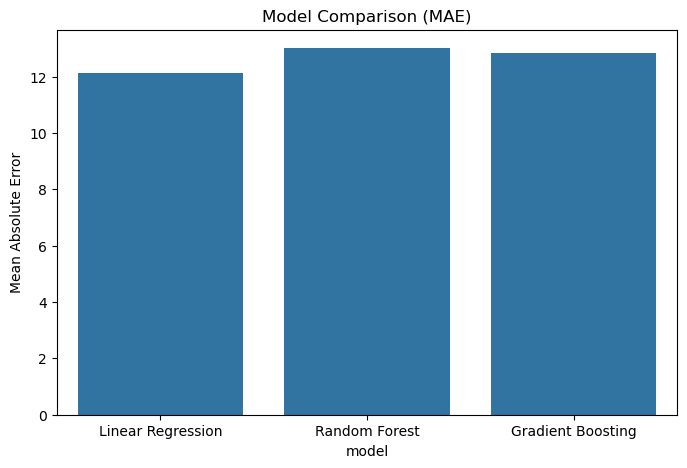

In [9]:
"""
Visualize model performance.
"""

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="model",
    y="MAE"
)

plt.title("Model Comparison (MAE)")

plt.ylabel("Mean Absolute Error")

plt.show()

In [10]:
"""
Evaluate best model using TimeSeriesSplit.
"""

tscv = TimeSeriesSplit(n_splits=5)

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

mae_scores = []

for train_idx, test_idx in tscv.split(X_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[test_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[test_idx]

    model.fit(X_tr, y_tr)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)

    mae_scores.append(mae)

print("Cross-validation MAE:", np.mean(mae_scores))

Cross-validation MAE: 15.116146422808686


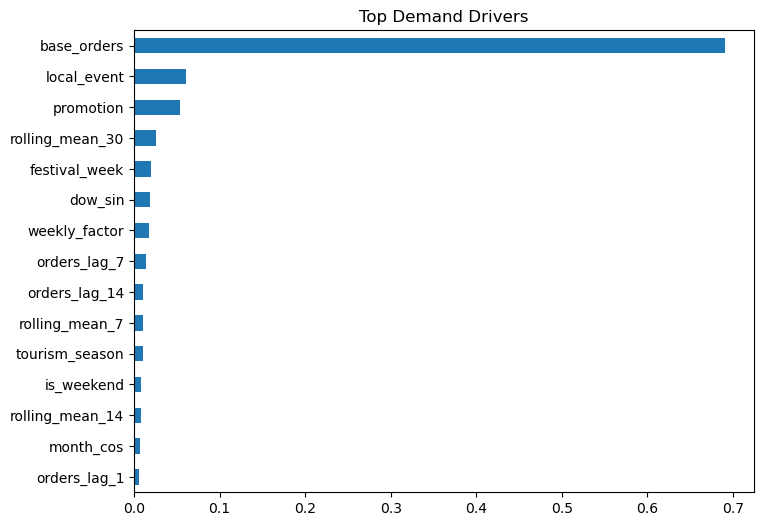

In [11]:
"""
Analyze feature importance from Gradient Boosting model.
"""

importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,6))

importances.head(15).plot(kind="barh")

plt.title("Top Demand Drivers")

plt.gca().invert_yaxis()

plt.show()

The feature importance analysis reveals that the model relies heavily on
the base demand component, which captures the fundamental structure of
restaurant demand.

External drivers such as promotions and local events also play an
important role in influencing daily orders.

Rolling averages and lag features help the model capture recent demand
trends and temporal dependencies.

Seasonal signals such as day-of-week patterns are also relevant
contributors to demand forecasting.

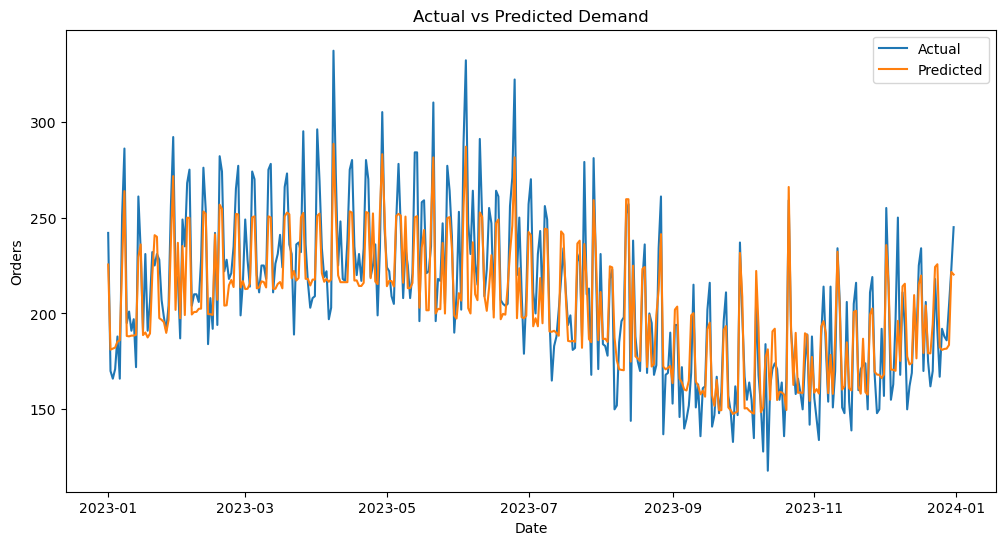

In [12]:
"""
Compare predicted vs actual demand.
"""

pred = model.predict(X_test)

plt.figure(figsize=(12,6))

plt.plot(test["date"], y_test, label="Actual")

plt.plot(test["date"], pred, label="Predicted")

plt.title("Actual vs Predicted Demand")

plt.xlabel("Date")
plt.ylabel("Orders")

plt.legend()

plt.show()

In [13]:
"""
Save trained model.
"""
joblib.dump(model, "../models/demand_forecasting_model.pkl")

print("Model saved successfully.")

Model saved successfully.


#### Model Training Summary

In this notebook we trained several machine learning models to forecast
daily restaurant demand using the engineered feature set.

A baseline model using the previous day's demand was first evaluated to
establish a reference performance.

Multiple machine learning algorithms were then trained and compared,
including:

• Linear Regression  
• Random Forest  
• Gradient Boosting  

The results show that ensemble models such as Gradient Boosting provide
the best predictive performance, as they are able to capture nonlinear
relationships and interactions between demand drivers.

Feature importance analysis revealed that the model relies primarily on:

• the base demand component  
• local events and promotions  
• rolling demand trends  
• seasonal patterns such as day-of-week effects  

These findings confirm that restaurant demand is influenced by a
combination of **temporal patterns, external drivers, and recent demand
dynamics**.

The trained model demonstrates strong predictive capability and will be
further analyzed in the next notebook using **model explainability
techniques** to better understand how individual features influence
predictions.